In [1]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from scipy.stats import chi2
import textwrap

# Dependency
* DGIDB_hypergraph
* Clustering_Result_Analysis

# Loading Variables

In [2]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

# Comm DGIDB genes count

In [3]:
def DGIDB_count(c,DGIDB_genes_ncbi):
    return set(c) & set(DGIDB_genes_ncbi)

In [4]:
with open(f"{DISEASE_FOLDER}/result_communities_ncbi_selected.pkl", "rb") as f:
    communities_ncbi_selected = pickle.load(f)
with open(f"{DISEASE_FOLDER}/result_communities_ncbi.pkl", "rb") as f:
    communities_ncbi = pickle.load(f)
with open(DGIDB_DIRECTORY + f"gene_to_index.json", "r") as file:
    DGIDB_gene_to_index = json.load(file)
DGIDB_genes = set(DGIDB_gene_to_index.keys())

In [5]:
comm_dgidb_gene_count = {}
for i in range(len(communities_ncbi_selected)):
    dgidb_genes_set = DGIDB_count(communities_ncbi[i],DGIDB_genes)
    print(i,len(dgidb_genes_set), dgidb_genes_set)
    print(len(communities_ncbi[i]))
    comm_dgidb_gene_count[i] = len(dgidb_genes_set)
    
with open(f"../output/{DISEASE}/comm_dgidb_gene_count.json","w") as f:
    json.dump(comm_dgidb_gene_count,f)    

0 0 set()
3540
1 0 set()
3433
2 0 set()
2961
3 0 set()
2708
4 0 set()
2337
5 0 set()
1585
6 0 set()
1411
7 0 set()
1354
8 0 set()
992
9 0 set()
496
10 0 set()
406
11 0 set()
347
12 300 {'3308', '28951', '2675', '36', '327', '1277', '2326', '6580', '652991', '1559', '8856', '10951', '5460', '3106', '1139', '6728', '8837', '7334', '3125', '5617', '2646', '345222', '3760', '7133', '265', '18', '236', '5565', '2740', '5020', '718', '26298', '5144', '51053', '3362', '51564', '10536', '54600', '262', '5009', '54658', '5428', '477', '2641', '2194', '1545', '23040', '632', '11201', '100302251', '2895', '7298', '153', '2947', '6311', '10014', '28755', '5468', '3552', '25970', '170679', '983', '319100', '9734', '116987', '6648', '3350', '79648', '2913', '3725', '7494', '3305', '4160', '6531', '9429', '64067', '79718', '3176', '1813', '1012', '4922', '5581', '10213', '80862', '5311', '8314', '214', '627', '4363', '360158', '1103', '215', '3269', '2950', '9759', '1555', '22', '54579', '6335', '884

# Important terms processing

In [6]:
with open(f"{DISEASE_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [7]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [8]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [9]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value)
0,0,934,Intra-Golgi And Retrograde Golgi-to-ER Traffic...,34/181,9.822686e-10,['Vesicle-mediated transport'],Reactome_2022,3.148297e-12,0.0,0.0,4.862026,128.766664,ARF3;ARF4;SCOC;TMF1;STX16;GOSR2;GOSR1;GOLIM4;G...,0.187845
1,0,934,Retrograde Transport At Trans-Golgi-Network R-...,17/48,3.490945e-09,['Vesicle-mediated transport'],Reactome_2022,2.237785e-11,0.0,0.0,11.383368,279.153755,SCOC;NAA30;TMF1;STX16;M6PR;GCC1;RABEPK;TGOLN2;...,0.354167
2,0,934,Membrane Trafficking R-HSA-199991,65/599,2.252254e-08,['Vesicle-mediated transport'],Reactome_2022,2.165629e-10,0.0,0.0,2.595820,57.765152,ARF3;ARF4;SCOC;MCFD2;C2CD5;GOLIM4;GCC1;CLINT1;...,0.108514
3,0,934,trans-Golgi Network (GO:0005802),36/241,1.527185e-07,['cellular anatomical structure'],GO_Cellular_Component_2023,6.471121e-10,0.0,0.0,3.688392,78.040838,SCOC;C17ORF75;STX16;ATP2C1;BICD1;RABEPK;ECPAS;...,0.149378
4,0,934,Vesicle-mediated Transport R-HSA-5653656,65/637,2.103912e-07,['Vesicle-mediated transport'],Reactome_2022,2.697324e-09,0.0,0.0,2.418402,47.717494,ARF3;ARF4;SCOC;MCFD2;C2CD5;GOLIM4;GCC1;CLINT1;...,0.102041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1728,12,134,Regulation Of Insulin Secretion R-HSA-422356,8/77,1.309870e-06,['Metabolism'],Reactome_2022,4.694075e-08,0.0,0.0,18.216701,307.395533,GLP1R;CHRM3;GNB3;CACNA1D;GCG;CACNA1C;ADRA2C;AD...,0.103896
1729,12,134,RUNX2 Regulates Bone Development R-HSA-8941326,6/31,1.381178e-06,['Gene expression (Transcription)'],Reactome_2022,5.185309e-08,0.0,0.0,37.201875,624.055922,HDAC4;COL1A1;HDAC3;SRC;BGLAP;HDAC6,0.193548
1730,12,134,Regulation Of PTEN Gene Transcription R-HSA-89...,7/61,3.916508e-06,['Signal Transduction'],Reactome_2022,1.670865e-07,0.0,0.0,20.222222,315.562803,HDAC5;HDAC2;HDAC3;GDNF;HDAC1;PPARG;HDAC7,0.114754
1731,12,134,Negative Regulation Of Striated Muscle Cell Di...,5/17,4.864172e-06,['biological regulation'],GO_Biological_Process_2023,7.264886e-08,0.0,0.0,64.127907,1054.110684,HDAC4;HDAC5;XBP1;HDAC3;HDAC1,0.294118


# Community Category df

In [ ]:
df = important_terms

# 1. Parse Category column (stringified list) -> list
df["Category"] = df["Category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# 2. Explode: one category per row
df_exp = df.explode("Category").reset_index(drop=True)

# 3. Parse Overlap "a/b" into numerator and denominator
_overlap = (
    df_exp["Overlap"]
    .str.split("/", expand=True)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)
df_exp["Overlap_num"] = _overlap[0]
df_exp["Overlap_den"] = _overlap[1]

# 4. Total number of terms per community
total_terms = df_exp.groupby("Community Index")["Term"].nunique()

# 5. Aggregate per (Community Index, Category)
def fisher_method(pvals):
    p = pd.Series(pvals).dropna().astype(float).clip(lower=1e-300)
    if len(p) == 0:
        return np.nan
    return float(chi2.sf(-2.0 * np.sum(np.log(p)), 2 * len(p)))

agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
        fisher_p=("Adjusted P-value", fisher_method),
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

community_categories = agg[[
    "Community Index", "Category", "count", "Gross Overlap",
    "fisher_p", "total_terms_in_comm", "frac_of_comm",
]].sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

community_categories

In [11]:
community_categories["fisher_score"] = -np.log10(
    community_categories["fisher_p"].clip(lower=1e-300)
)

mn = community_categories["fisher_score"].min()
mx = community_categories["fisher_score"].max()

community_categories["fisher_norm"] = (community_categories["fisher_score"] - mn) / (mx - mn)

def safe_z(x):
    mu = x.mean()
    sd = x.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=x.index)   # or return x*0
    return (x - mu) / sd

community_categories["fisher_z"] = (
    community_categories
    .groupby("Community Index")["fisher_score"]
    .transform(safe_z)
)




In [ ]:
# Save to CSV
community_categories.to_csv(DISEASE_FOLDER + "community_categories.csv", index=False)

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,localization,7,0.138662,5.178720e-33,13,0.538462,32.285778,0.092182,1.148982
1,0,cellular process,5,0.142128,3.318804e-23,13,0.384615,22.479018,0.058928,-0.072378
2,0,Vesicle-mediated transport,4,0.123549,1.106802e-27,13,0.307692,26.955930,0.074109,0.485188
3,0,cellular anatomical structure,2,0.167192,3.020280e-11,13,0.153846,10.519953,0.018375,-1.561792
4,1,cellular anatomical structure,7,0.128059,4.115189e-34,18,0.388889,33.385610,0.095912,1.045411
...,...,...,...,...,...,...,...,...,...,...
198,12,Disease,1,0.189655,9.125546e-12,36,0.027778,11.039741,0.020137,-0.732703
199,12,Endocrine and metabolic disease,1,0.186047,1.402626e-08,36,0.027778,7.853058,0.009331,-0.891992
200,12,Immune disease,1,0.142857,6.231355e-06,36,0.027778,5.205418,0.000353,-1.024336
201,12,Metabolism,1,0.103896,1.309870e-06,36,0.027778,5.882772,0.002650,-0.990478


In [49]:
top20_categories = (
    community_categories.groupby("Category")["fisher_z"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
      .index
)

community_categories_filtered = community_categories[community_categories["Category"].isin(top20_categories)].copy()

# Community Count Dict

In [ ]:
category_count_by_comm = {
    comm: {
        row["Category"]: (row["count"], row["Gross Overlap"])
        for _, row in group.iterrows()
    }
    for comm, group in community_categories.groupby("Community Index")
}

In [19]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [21]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)

# Heatmap with filtered categories

In [24]:
# list of index of top 5 highest DGIDB gene count
if DISEASE != "NONE":
    sorted_comm = sorted(comm_dgidb_gene_count.items(), key=lambda x: x[1], reverse=True)
    top_5_comm_indices = [idx for idx, count in sorted_comm[:5]]
else:
    top_5_comm_indices = important_terms["Community Index"].unique().tolist()


In [25]:
top_5_comm_indices

[12, 0, 1, 2, 3]

In [34]:
font_size = 13
tick_font_size = 13
plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": font_size,
    "axes.labelsize": 25,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


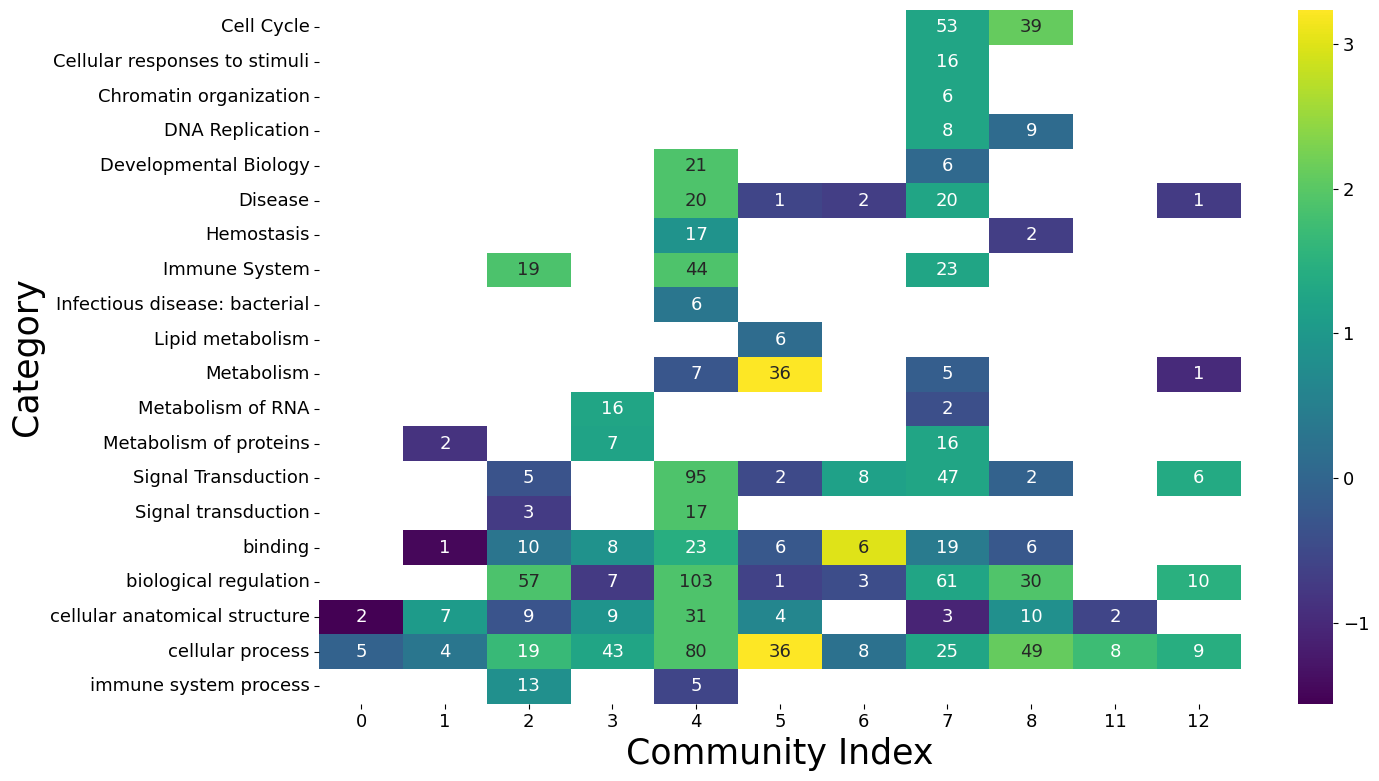

In [53]:
heat_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="fisher_z"
)

label_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="count"
)
plt.figure(figsize=(15, 8))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=label_df,   # <-- use count for labels
    fmt=".0f",        # integer labels
    cbar=True
)

# ---- WRAP Y-AXIS LABELS ----
MAX_CHARS = 50  # tweak this
wrapped = ["\n".join(textwrap.wrap(str(s), width=MAX_CHARS)) for s in heat_df.index]
ax.set_yticklabels(wrapped, rotation=0)  # keep horizontal

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/category_gross_overlap_heatmap.pdf", bbox_inches="tight", dpi = 300)
plt.show()


# Dominant categories and terms analysis

In [63]:
top_categories = (
    community_categories.groupby("Category")["fisher_z"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

In [64]:
top_categories

Category
Cell Cycle                       1.689050
Immune System                    1.680798
cellular process                 1.373634
Cellular responses to stimuli    1.267593
Chromatin organization           1.267593
Developmental Biology            0.979202
biological regulation            0.830117
Signal Transduction              0.683246
DNA Replication                  0.679209
Signal transduction              0.583450
Name: fisher_z, dtype: float64